In [1]:

import os
import random
import numpy as np

def set_global_seed(seed: int = 42):
    """
    Fully resets common randomness sources for reproducibility.
    """

    # Python RNG
    random.seed(seed)

    # NumPy RNG
    np.random.seed(seed)

    # Python hash seed (important for dict/set ordering consistency)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Optional: make numpy deterministic behavior more stable
    try:
        import numpy.random as npr
        npr.seed(seed)
    except Exception:
        pass

    # PyTorch (only if installed)
    try:
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # deterministic behavior (slower but reproducible)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    except Exception:
        pass

    # Gymnasium / Gym (if used)
    try:
        import gymnasium as gym
        gym.utils.seeding.np_random(seed)
    except Exception:
        pass

In [2]:
import random
import numpy as np


class BasePolicy:
    def __init__(self, env):
        self.env = env

    def select_action(self):
        raise NotImplementedError

    @staticmethod
    def _to_continuous(idx: int, n: int) -> float:
        if n <= 1:
            return 0.0
        return float(2.0 * idx / (n - 1) - 1.0)

    def _build_action(self, node_id, device_id):
        valid_nodes = self.env._get_valid_nodes()
        device_ids = sorted(self.env.devices.keys())

        if len(valid_nodes) == 0 or len(device_ids) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        try:
            node_idx = valid_nodes.index(node_id)
        except ValueError:
            node_idx = 0

        try:
            device_idx = device_ids.index(device_id)
        except ValueError:
            device_idx = 0

        node_signal = self._to_continuous(node_idx, len(valid_nodes))
        device_signal = self._to_continuous(device_idx, len(device_ids))

        return np.array([node_signal, device_signal], dtype=np.float32)

    def _valid_nodes(self):
        return self.env._get_valid_nodes()

    def _device_load(self, device_id):
        return sum(
            1
            for info in self.env.scheduler.node_schedule_info.values()
            if info["device_id"] == device_id
        )

    def _device_finish_time(self, device_id):
        device = self.env.devices[device_id]
        return max(
            (processor.available_time for processor in device.processors),
            default=0.0,
        )


class Random(BasePolicy):
    def select_action(self):
        valid_nodes = self._valid_nodes()
        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        node_id = random.choice(valid_nodes)
        device_id = random.choice(list(self.env.devices.keys()))

        return self._build_action(node_id, device_id)


class Local(BasePolicy):
    def select_action(self):
        valid_nodes = self._valid_nodes()
        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        node_id = valid_nodes[0]

        # نودها از جنس (task_id, node_id) هستند.
        # local یعنی اجرای task روی VE متناظر خودش.
        if isinstance(node_id, tuple):
            task_id, _ = node_id
            device_id = task_id if task_id in self.env.devices else 0
        else:
            device_id = 0

        return self._build_action(node_id, device_id)

import numpy as np


class Remote(BasePolicy):

    def __init__(self, env):
        super().__init__(env)

    def _nearest_ves(self, node_id):

        if not isinstance(node_id, tuple):
            return 0

        task_id, _ = node_id

        producer = self.env.devices[task_id]

        best_ves = None
        best_distance = float("inf")

        for device_id, device in self.env.devices.items():

            if device.node_type != "VES":
                continue

            distance = (
                (producer.x - device.x) ** 2
                + (producer.y - device.y) ** 2
            ) ** 0.5

            if distance < best_distance:
                best_distance = distance
                best_ves = device_id

        if best_ves is None:
            raise RuntimeError(
                "No VES found for Remote policy."
            )

        return best_ves

    def select_action(self):

        valid_nodes = self._valid_nodes()

        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        node_id = valid_nodes[0]

        device_id = self._nearest_ves(node_id)

        return self._build_action(
            node_id=node_id,
            device_id=device_id,
        )
class Greedy(BasePolicy):
    def _score(self, node_id, device_id):
        attr = self.env.dag.nodes[node_id]

        cpu_cycles = float(attr["cpu_cycles"])
        compute_power = float(self.env.devices[device_id].compute_power)

        exec_time = cpu_cycles / max(compute_power, 1.0)
        queue_load = float(self._device_load(device_id))
        finish_time = float(self._device_finish_time(device_id))

        # bonus کوچک برای local placement
        local_bonus = 0.0
        if isinstance(node_id, tuple):
            task_id, _ = node_id
            if task_id in self.env.devices and device_id == task_id:
                local_bonus = 0.1

        # هرچه score کمتر باشد بهتر است
        return exec_time + 0.15 * finish_time + 0.05 * queue_load - local_bonus

    def select_action(self):
        valid_nodes = self._valid_nodes()
        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        device_ids = sorted(self.env.devices.keys())

        best_score = float("inf")
        best_node = valid_nodes[0]
        best_device = device_ids[0]

        for node_id in valid_nodes:
            for device_id in device_ids:
                score = self._score(node_id, device_id)
                if score < best_score:
                    best_score = score
                    best_node = node_id
                    best_device = device_id

        return self._build_action(best_node, best_device)

In [3]:
from copy import deepcopy

import networkx as nx
import numpy as np

from env.scheduler import Scheduler


class RoundRobinEvaluator:

    def __init__(self, env):
        self.env = env

    def _mean_cft(self, scheduler):

        task_finish_times = {}

        for node, info in scheduler.node_schedule_info.items():

            task_id = node[0]

            task_finish_times[task_id] = max(
                task_finish_times.get(task_id, 0.0),
                info["CT"]
            )

        return float(
            np.mean(
                list(task_finish_times.values())
            )
        )

    def _local_baseline(self):

        scheduler = Scheduler(
            dag=deepcopy(self.env.dag),
            transmission_model=self.env.transmission_model,
            devices=deepcopy(self.env.devices),
        )

        topo_order = list(
            nx.topological_sort(
                scheduler.dag
            )
        )

        for node in topo_order:

            if node == 0:
                continue

            if not isinstance(node, tuple):
                continue

            if scheduler.dag.nodes[node]["cpu_cycles"] == 0:
                continue

            scheduler.schedule_node(
                node_id=node,
                device_id=node[0]
            )

        return self._mean_cft(
            scheduler
        )

    def evaluate(self):

        scheduler = Scheduler(
            dag=deepcopy(self.env.dag),
            transmission_model=self.env.transmission_model,
            devices=deepcopy(self.env.devices),
        )

        ves_ids = sorted(
            [
                device_id
                for device_id, device
                in self.env.devices.items()
                if device.node_type == "VES"
            ]
        )

        if len(ves_ids) == 0:
            raise RuntimeError(
                "No VES found for RR scheduling."
            )

        topo_order = list(
            nx.topological_sort(
                scheduler.dag
            )
        )

        rr_index = 0

        for node in topo_order:

            if node == 0:
                continue

            if not isinstance(node, tuple):
                continue

            if scheduler.dag.nodes[node]["cpu_cycles"] == 0:
                continue

            device_id = ves_ids[
                rr_index % len(ves_ids)
            ]

            scheduler.schedule_node(
                node_id=node,
                device_id=device_id
            )

            rr_index += 1

        mean_cft = self._mean_cft(
            scheduler
        )

        baseline_cft = self._local_baseline()

        return {
            "reward": 0.0,
            "mean_cft": mean_cft,
            "baseline_cft": baseline_cft,
            "normalized_cft": (
                mean_cft /
                max(baseline_cft, 1e-9)
            ),
        }

In [4]:
import numpy as np
import pandas as pd

from stable_baselines3 import TD3, DDPG # type: ignore
from model.dvtp_policy import DVTPPPO
from model.improved_model import IMPDVTP

# فرض بر این است که کدهای بالا مانند تعریف Random، Local، Greedy و set_global_seed قبلاً Import شده‌اند.

# =========================================================
# helper: single episode runner
# =========================================================
def _run_single_episode(env, agent, max_steps, is_sb3=False):
    obs, _ = env.reset()
    rewards = []
    terminated = False
    truncated = False
    step_count = 0
    last_metrics = None

    while (not terminated) and (not truncated) and step_count < max_steps:
        if is_sb3:
            action, _ = agent.predict(obs, deterministic=True)
        else:
            action = agent.select_action()

        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(float(reward))
        last_metrics = info
        step_count += 1

    # ============================
    # CFT-based final evaluation
    # ============================
    mean_cft = float(last_metrics.get("mean_cft", 0.0)) if last_metrics else 0.0
    baseline = float(last_metrics.get("baseline_cft", 0.0)) if last_metrics else 0.0

    # lower is better → keep raw CFT and normalized improvement
    return {
        "reward": np.sum(rewards),
        "mean_cft": mean_cft,
        "normalized_cft": mean_cft / (baseline + 1e-9),
    }


# =========================================================
# main benchmark
# =========================================================
def evaluate_all_algorithms(
    num_ve,
    num_ves,
    num_nodes,
    max_steps,
    num_learn,
    num_eval_episodes=10,
    experiment=False
):
    from env.my_env import VEC

    print("=" * 60)
    print("Benchmark started")
    print("=" * 60)
    
    # =====================================================
    # Training phase
    # =====================================================
    if not experiment:
        # TD3 training
        td3_env = VEC(num_ve=num_ve, num_ves=num_ves, num_nodes=num_nodes)
        td3_model = TD3(
            "MultiInputPolicy",
            td3_env,
            buffer_size=10000,
            batch_size=64,
            verbose=0
        )
        td3_model.learn(total_timesteps=num_learn, progress_bar=True)

        # DVTPPPO training
        dvt_env = VEC(num_ve=num_ve, num_ves=num_ves, num_nodes=num_nodes)
        dvt_model = DVTPPPO(dvt_env)
        dvt_model.learn(num_learn)

    # =====================================================
    # algorithms list
    # =====================================================
    algorithms = [
        ("Random", Random, "heuristic"),
        ("Local", Local, "heuristic"),
        # ("Remote", Remote, "heuristic"),
        # ("Greedy", Greedy, "heuristic"),
        ("RR", RoundRobinEvaluator, "rr"),
    ]

    if not experiment:
        algorithms.append(("TD3", td3_model, "sb3"))
        algorithms.append(("DVTPPPO", dvt_model, "sb3"))

    rows = []

    # =====================================================
    # evaluation loop
    # =====================================================
    for algo_idx, (algo_name, algo, algo_type) in enumerate(algorithms):
        print(f"Evaluating {algo_name} ({algo_idx+1}/{len(algorithms)})...")
        
        cfts = []
        norm_cfts = []
        rewards = []

        for ep in range(num_eval_episodes):
            # # اگر می‌خواهی محیط در هر اپیزود دقیقاً رفتار یکسانی داشته باشد، سید را نگه دار. 
            # # اگر می‌خواهی در محیط‌های تصادفی مختلف تست شود، set_global_seed را حذف یا داینامیک کن.
            # set_global_seed(42 + random.randint(ep,11 * ep)) 
            
            env = VEC(num_ve=num_ve, num_ves=num_ves, num_nodes=num_nodes)


            if algo_type == "heuristic":
                agent = algo(env)
                result = _run_single_episode(env, agent, max_steps, is_sb3=False)

            elif algo_type == "rr":

                env.reset()

                rr = algo(env)
                
                result = rr.evaluate()
            else:
                result = _run_single_episode(env, algo, max_steps, is_sb3=True)

            cfts.append(result["mean_cft"])
            norm_cfts.append(result["normalized_cft"])
            rewards.append(result["reward"])

        # میانگین‌گیری نتایج تمام اپیزودها برای الگوریتم فعلی
        row = {
            "algorithm": algo_name,
            "mean_reward": np.mean(rewards),
            "mean_cft": np.mean(cfts),
            "normalized_cft": np.mean(norm_cfts),
        }
        rows.append(row)

    print("\n" + "=" * 60)
    print("Benchmark finished")
    print("=" * 60)

    return pd.DataFrame(rows)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_benchmark_sweep(
    dfs,
    x_values,
    x_label="VE",
    metrics=("mean_cft", "mean_reward"),
    algorithms=None,
):
    """
    dfs: list[pd.DataFrame]
        خروجی evaluate_all_algorithms برای هر مقدار x

    x_values: list
        مثلا [2, 4, 6, 8, 10]

    x_label: str
        نام محور x

    metrics: tuple
        متریک‌هایی که رسم می‌شوند (اکنون CFT-based)

    algorithms: list[str] or None
    """

    if algorithms is None:
        algorithms = dfs[0]["algorithm"].tolist()

    def get_value(df, algo, metric):
        row = df[df["algorithm"] == algo]
        if len(row) == 0:
            return np.nan
        return float(row.iloc[0][metric])

    for metric in metrics:

        plt.figure(figsize=(7, 5))

        for algo in algorithms:

            y = [
                get_value(df, algo, metric)
                for df in dfs
            ]

            # CFT optimization: lower is better → invert plot view if desired
            plt.plot(
                x_values,
                y,
                marker="o",
                linewidth=2,
                label=algo,
            )

        plt.xlabel(x_label)
        plt.ylabel(metric)
        plt.title(f"{metric} vs {x_label}")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished


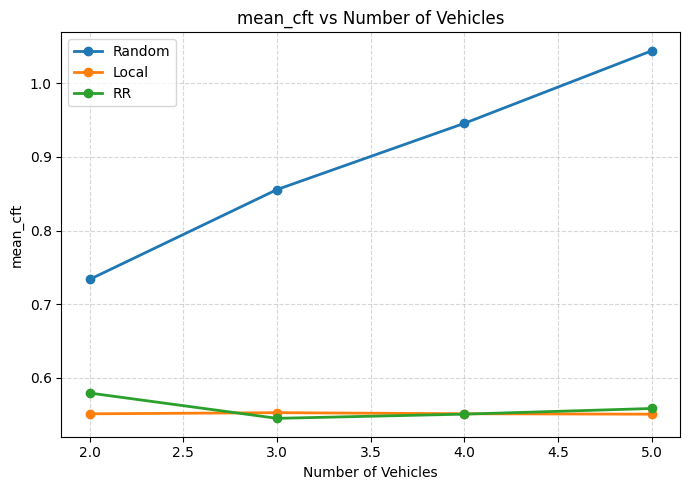

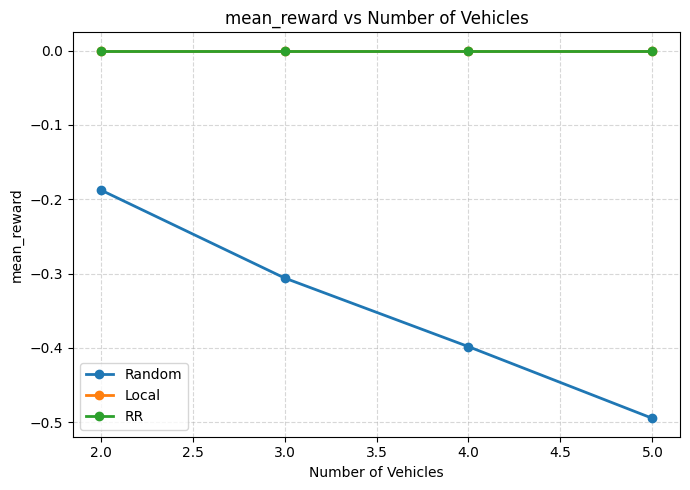

[  algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -1.874340e-01  0.733707        1.355066
 1     Local -2.331468e-18  0.551369        1.000000
 2        RR  0.000000e+00  0.579583        1.064508,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -3.060319e-01  0.855677        1.566211
 1     Local -1.554312e-18  0.552909        1.000000
 2        RR  0.000000e+00  0.545230        0.997049,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -3.984732e-01  0.945625        1.734382
 1     Local -7.771561e-19  0.551474        1.000000
 2        RR  0.000000e+00  0.550929        1.005503,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -4.950004e-01  1.044112        1.907299
 1     Local  2.331468e-18  0.550864        1.000000
 2        RR  0.000000e+00  0.558595        1.019124]

In [7]:
ve_list = [2, 3, 4, 5]

dfs = []

for ve in ve_list:
    df = evaluate_all_algorithms(
        num_ve=ve,
        num_ves=5,
        num_nodes=10,
        max_steps=15_000,
        num_learn=15_000,
        num_eval_episodes=1000,
        experiment=True
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ve_list,
    x_label="Number of Vehicles"
)
dfs

Benchmark started
Evaluating Random (1/4)...
Evaluating Local (2/4)...
Evaluating Remote (3/4)...
Evaluating RR (4/4)...

Benchmark finished
Benchmark started
Evaluating Random (1/4)...
Evaluating Local (2/4)...
Evaluating Remote (3/4)...
Evaluating RR (4/4)...

Benchmark finished
Benchmark started
Evaluating Random (1/4)...
Evaluating Local (2/4)...
Evaluating Remote (3/4)...
Evaluating RR (4/4)...

Benchmark finished
Benchmark started
Evaluating Random (1/4)...
Evaluating Local (2/4)...
Evaluating Remote (3/4)...
Evaluating RR (4/4)...

Benchmark finished


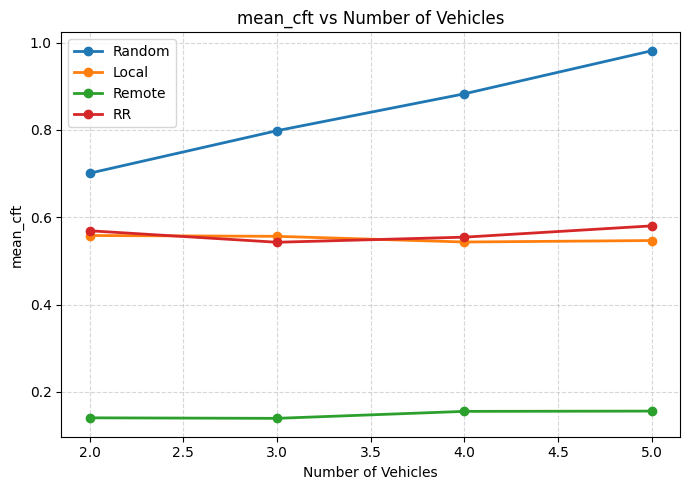

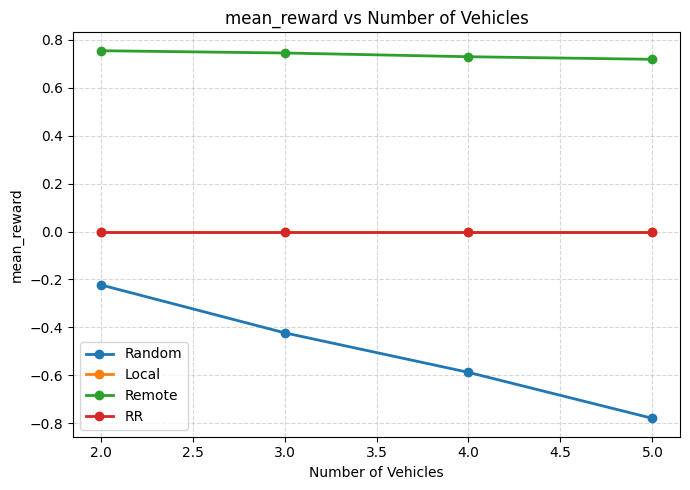

[  algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -2.223052e-01  0.700879        1.246371
 1     Local  1.031321e-17  0.558191        1.000000
 2    Remote  7.537580e-01  0.140448        0.254357
 3        RR  0.000000e+00  0.569063        1.091019,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -4.222752e-01  0.798339        1.472758
 1     Local -1.056850e-19  0.556325        1.000000
 2    Remote  7.442839e-01  0.139285        0.256244
 3        RR  0.000000e+00  0.542728        1.014678,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -5.872314e-01  0.882886        1.608244
 1     Local -1.119111e-17  0.543303        1.000000
 2    Remote  7.287079e-01  0.155256        0.283445
 3        RR  0.000000e+00  0.554410        1.007250,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -7.789145e-01  0.981582        1.803096
 1     Local -1.744439e-17  0.546682        1.000000
 2    Remote  7.179154e-01  0.155862       

In [6]:
ve_list = [2, 3, 4, 5]

dfs = []

for ve in ve_list:
    df = evaluate_all_algorithms(
        num_ve=ve,
        num_ves=5,
        num_nodes=10,
        max_steps=15_000,
        num_learn=15_000,
        num_eval_episodes=20,
        experiment=True
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ve_list,
    x_label="Number of Vehicles"
)
dfs

Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished
Benchmark started
Evaluating Random (1/3)...
Evaluating Local (2/3)...
Evaluating RR (3/3)...

Benchmark finished


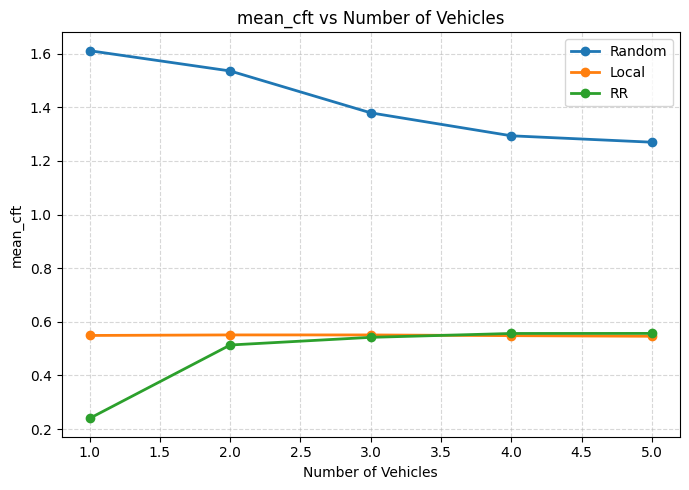

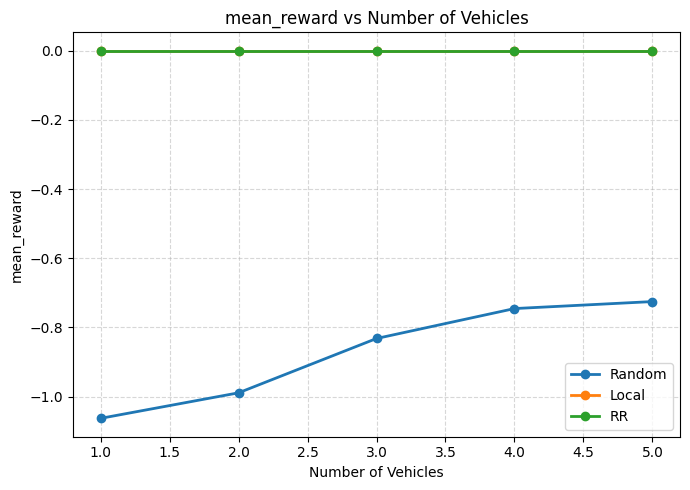

[  algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -1.062765e+00  1.610825        2.942588
 1     Local  4.996004e-18  0.549100        1.000000
 2        RR  0.000000e+00  0.240056        0.434947,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -9.889577e-01  1.535295        2.812285
 1     Local  1.665335e-18  0.551112        1.000000
 2        RR  0.000000e+00  0.513539        0.935460,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -8.319431e-01  1.379119        2.518719
 1     Local  7.216450e-18  0.551042        1.000000
 2        RR  0.000000e+00  0.542095        0.984491,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -7.454239e-01  1.293565        2.363861
 1     Local -6.106227e-18  0.548347        1.000000
 2        RR  0.000000e+00  0.556499        1.009890,
   algorithm   mean_reward  mean_cft  normalized_cft
 0    Random -7.252025e-01  1.269693        2.334582
 1     Local  4.440892e-18  0.546075      

In [8]:
ves_list = [1, 2, 3, 4, 5]

dfs = []

for ves in ves_list:
    df = evaluate_all_algorithms(
        num_ve=8,
        num_ves=ves,
        num_nodes=10,
        max_steps=20_000,
        num_learn=20_000,
        num_eval_episodes=100,
        experiment=True
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ves_list,
    x_label="Number of Vehicles"
)
dfs